In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/processed/cleaned_supply_chain_no_fraud.csv')

In [4]:
df.columns.to_list()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Id',
 'Customer Segment',
 'Customer State',
 'Customer Zipcode',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode']

In [5]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

In [8]:
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [9]:
df.dtypes[['order date (DateOrders)', 'shipping date (DateOrders)']]

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

In [10]:
df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')
monthly_demand = df.groupby('order_month')['Order Item Quantity'].sum()
monthly_demand

order_month
2015-01    11568
2015-02    10193
2015-03    11784
2015-04    11083
2015-05    11580
2015-06    10935
2015-07    11558
2015-08    11371
2015-09    11086
2015-10    11432
2015-11    11257
2015-12    11538
2016-01    11394
2016-02    10479
2016-03    11104
2016-04    10918
2016-05    11360
2016-06    10789
2016-07    11263
2016-08    11528
2016-09    11095
2016-10    11723
2016-11    11220
2016-12    11484
2017-01    11366
2017-02    10784
2017-03    11483
2017-04    10933
2017-05    10732
2017-06     9924
2017-07    10792
2017-08    10843
2017-09    10260
2017-10     2439
2017-11     2006
2017-12     2077
2018-01     2082
Freq: M, Name: Order Item Quantity, dtype: int64

In [11]:
df['after_drop'] = (df['order_month'] >= '2017-10').astype(int)

In [14]:
df[['order_month', 'after_drop']].drop_duplicates().sort_values('order_month').tail(10)

,order_month,after_drop
73,2017-04,0
74,2017-05,0
78,2017-06,0
62,2017-07,0
63,2017-08,0
70,2017-09,0
144,2017-10,1
143,2017-11,1
225,2017-12,1
0,2018-01,1


<Axes: title={'center': 'Monthly Demand (Order Item Quantity)'}, xlabel='order_month'>

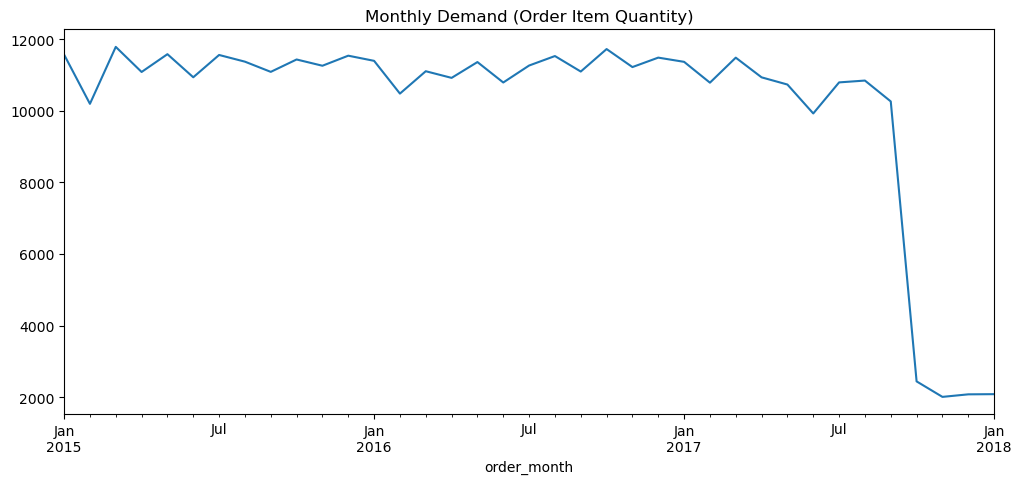

In [15]:
monthly_demand.plot(figsize = (12,5), title = 'Monthly Demand (Order Item Quantity)')

In [20]:
demand_df = monthly_demand.reset_index()
demand_df.columns = ['month', 'demand']
demand_df['time_trend']= range(len(demand_df))
demand_df['after_drop'] = (demand_df['month'] >= '2017-10').astype(int)
demand_df.tail(10)

,month,demand,time_trend,after_drop
27,2017-04,10933,27,0
28,2017-05,10732,28,0
29,2017-06,9924,29,0
30,2017-07,10792,30,0
31,2017-08,10843,31,0
32,2017-09,10260,32,0
33,2017-10,2439,33,1
34,2017-11,2006,34,1
35,2017-12,2077,35,1
36,2018-01,2082,36,1


In [22]:
import statsmodels.api as sm

X = demand_df[['time_trend', 'after_drop']]
X = sm.add_constant(X)
y = demand_df['demand']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     849.1
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           9.53e-30
Time:                        17:00:00   Log-Likelihood:                -273.68
No. Observations:                  37   AIC:                             553.4
Df Residuals:                      34   BIC:                             558.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.139e+04    140.011     81.361      0.0

a simple linear model explains 98% of monthly demand variation using only a time trend and a single structural break flag, confirming the October 2017 drop as a real, statistically significant 8,649 unit decline

In [23]:
import matplotlib.pyplot as plt

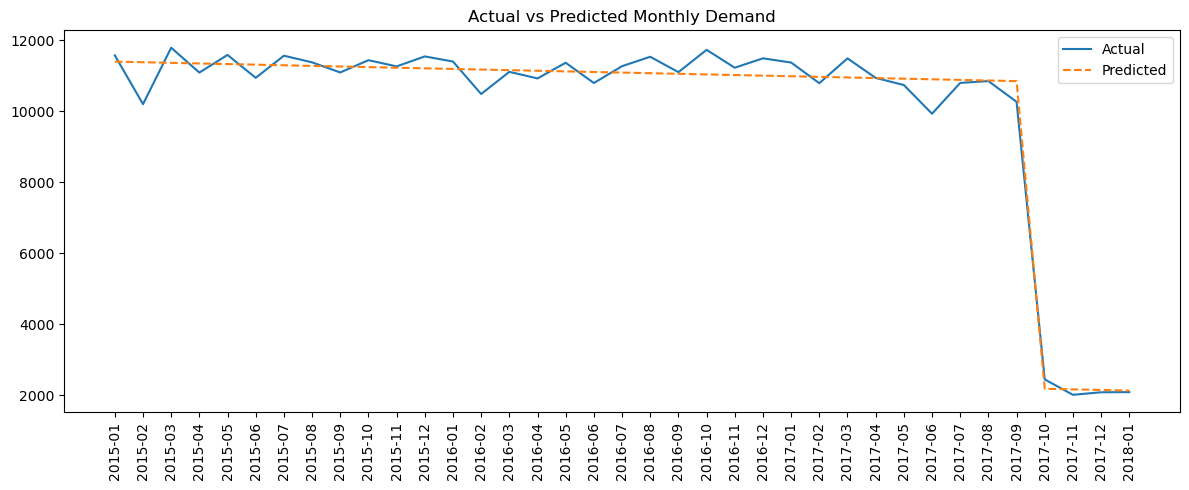

In [24]:
demand_df['predicted'] = model.predict(X)
plt.figure(figsize = (12,5))
plt.plot(demand_df['month'].astype(str), demand_df['demand'], label = 'Actual')
plt.plot(demand_df['month'].astype(str), demand_df['predicted'], label = 'Predicted', linestyle = '--')
plt.xticks(rotation=90)
plt.legend()
plt.title('Actual vs Predicted Monthly Demand')
plt.tight_layout()
plt.show()
         

In [25]:
#predicting future month
future_months = pd.period_range('2018-02', periods = 6, freq='M')
future_df = pd.DataFrame({'month': future_months})
future_df['time_trend'] = range(len(demand_df), len(demand_df) + len(future_df))
future_df['after_drop'] = 1

X_future = sm.add_constant(future_df[['time_trend','after_drop']], has_constant = 'add')
future_df['forecast'] = model.predict(X_future)
future_df

,month,time_trend,after_drop,forecast
0,2018-02,37,1,2108.109610
1,2018-03,38,1,2090.953453
2,2018-04,39,1,2073.797297
3,2018-05,40,1,2056.641141
4,2018-06,41,1,2039.484985
5,2018-07,42,1,2022.328829


In [27]:
pre_drop = demand_df[demand_df['after_drop'] == 0]

X_pre = sm.add_constant(pre_drop[['time_trend']])
Y_pre = pre_drop['demand']

model_pre = sm.OLS(Y_pre, X_pre).fit()
print(model_pre.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     4.745
Date:                Sun, 09 Aug 2026   Prob (F-statistic):             0.0371
Time:                        17:42:19   Log-Likelihood:                -245.69
No. Observations:                  33   AIC:                             495.4
Df Residuals:                      31   BIC:                             498.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.139e+04    145.459     78.298      0.0

In [28]:
post_drop = demand_df[demand_df['after_drop'] == 1]
flat_forecast = post_drop['demand'].mean()
flat_std = post_drop['demand'].std()

print(f"Flat forecast: {flat_forecast:.0f}")
print(f"Std dev (spread) of the 4 known post-drop months:{flat_std:.0f}")

Flat forecast: 2151
Std dev (spread) of the 4 known post-drop months:195


In [29]:
print(f"Forecast range: {flat_forecast - flat_std:.0f} to {flat_forecast + flat_std:.0f} units/month")

Forecast range: 1956 to 2346 units/month


After EDA and data cleaning, we found a sharp demand drop starting October 2017. Given the limited data available (only 4 months post-drop), a full time series model risked overfitting; linear regression using a time trend and a post-drop indicator was chosen as an appropriate, more transparent baseline. The combined model achieved an R-squared of 0.98, meaning time trend and the drop indicator together explain 98% of the variation in monthly demand. However, isolating the time trend alone (pre-drop months only) showed it explains just % of variation on its own - revealing the trend is weak and shouldn't be extrapolated forward into the post-drop period. Instead, the 6-month forecast uses a flat estimate based on the post-drop period. Instead, the 6-month forecast uses a flat esitmate based on the post-drop average(2,151 units/month, +- 195), explicitly acknowledging the limited evidence behind it rather than projecting false precision.